EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
df = pd.read_csv('data/train.csv')

Рассмотрим SalePrice, из графика будет видно что присутствует правосторонняя ассиметрия - график сильно растягивается вправо. Справа - дома с очень высокой ценой, и если оставить все как есть, то модель может начать ошибаться на них, они будут для нее аномалиями.

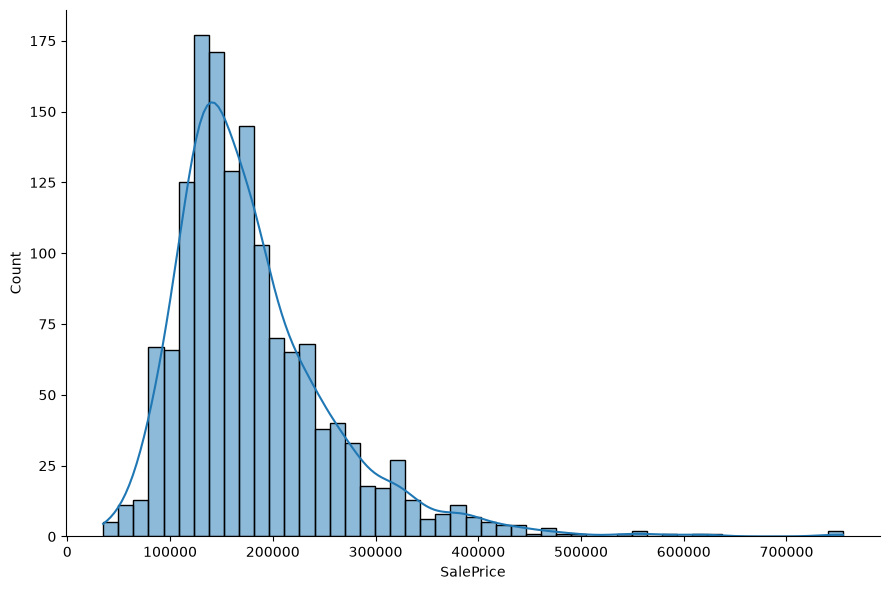

In [3]:
sns.displot(train['SalePrice'], kde=True, height=6, aspect=1.5)

Регрессионные модели лучше работают с нормальным распределением - симметрией. Поэтому можно применить логарифмирование для этой фичи (она же является целевой переменной).

In [4]:
train['SalePriceLog'] = np.log1p(train['SalePrice']) # создаем нужный нам логарифмированный таргет для обучения
train = train.drop(columns=['SalePrice'])

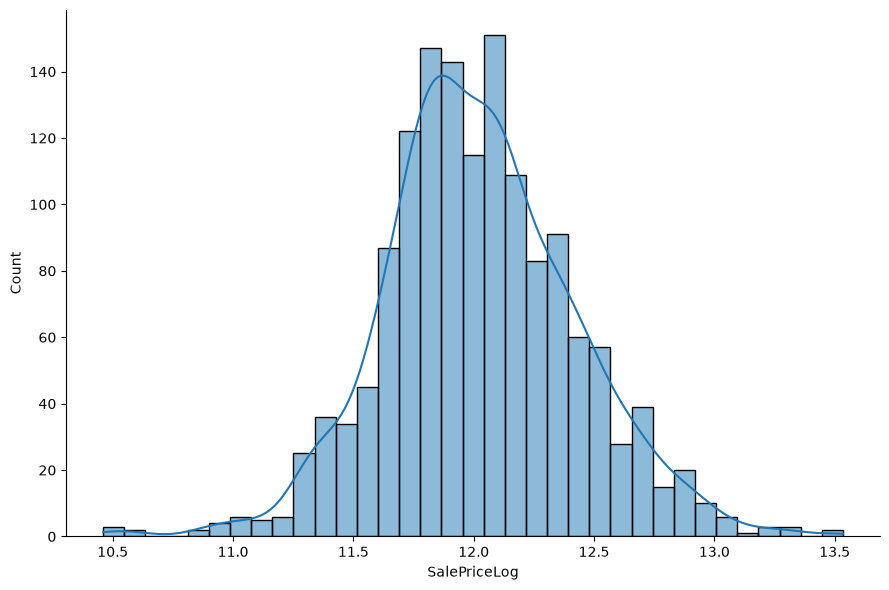

In [5]:
sns.displot(train['SalePriceLog'], kde=True, height=6, aspect=1.5)

Глянем сколько фичей, пропусков, типы данных

In [6]:
print(train.shape)
print(train.dtypes.value_counts())
print(train.isnull().sum().sort_values(ascending=False).head(22))

(1460, 81)
str        43
int64      34
float64     4
Name: count, dtype: int64
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
dtype: int64


<span style="font-size: 13px;">
PoolQC: NA	No Pool

MiscFeature (Miscellaneous feature not covered in other categories): NA	None

Alley (Type of alley access to property): NA No alley access

Fence (Fence quality): NA No Fence

MasVnrType (Masonry veneer type): None None

FireplaceQu (Fireplace quality): NA	No Fireplace

LotFrontage: Linear feet of street connected to property (no info about NA)

GarageType (Garage location): NA No Garage

GarageQual: NA No Garage

GarageFinish: NA No Garage

GarageYrBlt: Year garage was built (no info about NA)

BsmtQual (Evaluates the height of the basement): NA No Basement

BsmtExposure: NA No Garage

BsmtFinType1: NA No Garage

BsmtFinType2: NA No Garage

BsmtCond: NA No Garage

MasVnrType: None None

Electrical: no info about NA
</span>

<span style="font-size: 14px;">
Для дальнейшего анализа пропусков разделим вышеописанные фичи на 3 Группы.

Группа 1. NaN для категориальной фичи, означающая что объекта нет [(no fireplace, no pool, no garage, etc.), (PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType, GarageQual, GarageFinish, BsmtQual, BsmtExposure, BsmtFinType1, BsmtFinType2, BsmtCond)]

Группа 2. NaN для числовой фичи, означающая что объекта нет [(no garage year built, etc.) (GarageYrBlt, MasVnrArea)]

Группа 3. Реальные пропуски (LotFrontage, Electrical).
</span>

In [7]:
# == Missing Values ==

# -- Group 1 --
cat_none_cols = [ 
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageQual', 'GarageCond', 'GarageFinish', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtCond'
]
for col in cat_none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# -- Group 2 --
num_zero_cols = [
    'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]
for col in num_zero_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# -- Group 3 --
lot_median_by_neighborhood = train.groupby('Neighborhood')['LotFrontage'].median()
train['LotFrontage'] = train['LotFrontage'].fillna(
    train['Neighborhood'].map(lot_median_by_neighborhood)
)
test['LotFrontage'] = test['LotFrontage'].fillna(
    test['Neighborhood'].map(lot_median_by_neighborhood)
)

train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])
train['MasVnrType'] = train['MasVnrType'].fillna(train['MasVnrType'].mode()[0])
test['MasVnrType'] = test['MasVnrType'].fillna(train['MasVnrType'].mode()[0])

test_mode_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
for col in test_mode_cols:
    test[col]= test[col].fillna(train[col].mode()[0])

print("Train remaining NaN:", train.isnull().sum().sum())
print("Test remaining NaN:", test.isnull().sum().sum())

Train remaining NaN: 0
Test remaining NaN: 0


Начнем рассматривать корреляцию числовых фичей с SalePrice

In [8]:
numeric_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

correlation = train[numeric_features].corr()['SalePriceLog'].sort_values(ascending=False)
print (correlation)

SalePriceLog     1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.426776
BsmtFinSF1       0.372023
LotFrontage      0.353288
GarageYrBlt      0.349013
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

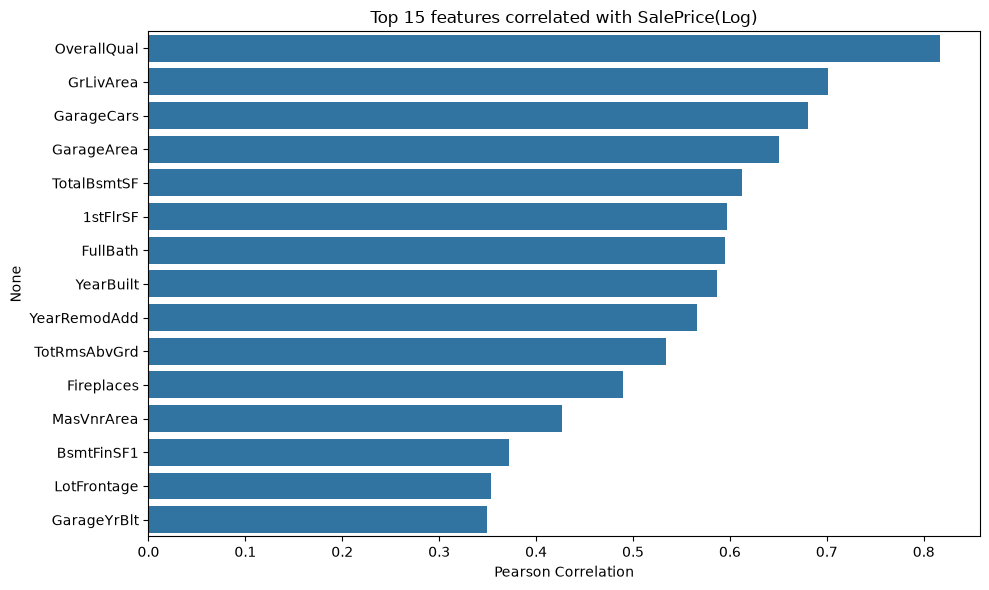

In [9]:
top_corr = correlation.drop('SalePriceLog').head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top 15 features correlated with SalePrice(Log)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

OverallQual(общее качество) принимает только целые значения (1-10), поэтому scatter plot даст просто 10 вертикальных полос из точек. Будем использовать box plot.
GrLivArea(жилая площадь на уровне земли) непрерывная числовая фича, для нее подходит scatter plot.

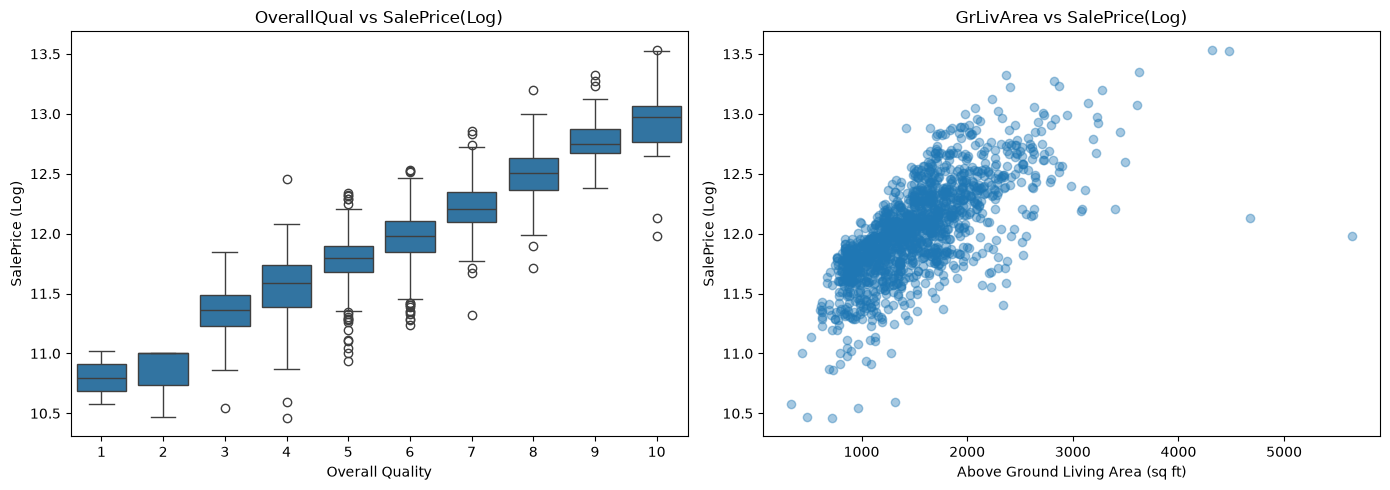

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OverallQual — порядковая (1-10), лучше boxplot
sns.boxplot(x=train['OverallQual'], y=train['SalePriceLog'], ax=axes[0])
axes[0].set_title('OverallQual vs SalePrice(Log)')
axes[0].set_xlabel('Overall Quality')
axes[0].set_ylabel('SalePrice (Log)')

# GrLivArea — непрерывная, scatter plot
axes[1].scatter(train['GrLivArea'], train['SalePriceLog'], alpha=0.4)
axes[1].set_title('GrLivArea vs SalePrice(Log)')
axes[1].set_xlabel('Above Ground Living Area (sq ft)')
axes[1].set_ylabel('SalePrice (Log)')

plt.tight_layout()
plt.show()

Проверим выбросы GrLivArea, те что >4000 sq ft.

In [11]:
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePriceLog'] < 12.5)]
print(outliers[['GrLivArea', 'SalePriceLog']])
print(f'Кол-во выбросов:{len(outliers)}')

      GrLivArea  SalePriceLog
523        4676     12.126764
1298       5642     11.982935
Кол-во выбросов:2


Явно прослеживается нестанадартная ситуация для данных двух домов. Цена слишком низка для подобных квадратур.
В данном случае мы дропаем их.

In [12]:
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePriceLog'] < 12.5)].index)
print(f'Train size after dropping outliers: {len(train)}')

Train size after dropping outliers: 1458


Рассмотрим интересную фичу 'Neighborhood' и ее связь с SalePrice

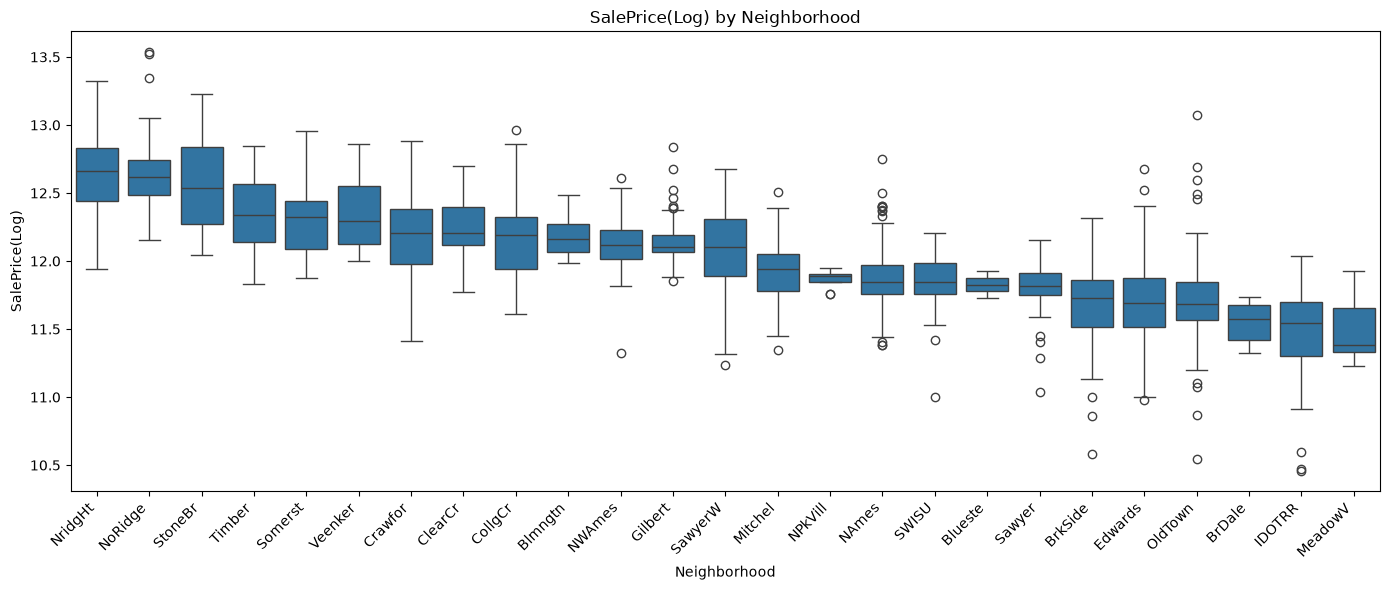

                 median  count
Neighborhood                  
NridgHt       12.660331     77
NoRidge       12.616529     41
StoneBr       12.535380     25
Timber        12.339184     38
Somerst       12.326077     86
Veenker       12.292255     11
Crawfor       12.209193     51
ClearCr       12.207326     28
CollgCr       12.191972    150
Blmngtn       12.160034     17
NWAmes        12.116700     73
Gilbert       12.106258     79
SawyerW       12.100162     59
Mitchel       11.941462     49
NPkVill       11.891369      9
NAmes         11.849405    225
SWISU         11.845827     25
Blueste       11.826543      2
Sawyer        11.813037     74
BrkSide       11.730225     58
Edwards       11.691071     98
OldTown       11.686887    113
BrDale        11.571204     16
IDOTRR        11.542494     37
MeadowV       11.385103     17


In [13]:
neighborhood_stats = train.groupby('Neighborhood')['SalePriceLog'].agg(['median', 'count']).sort_values('median', ascending=False)

plt.figure(figsize=(14,6))
sns.boxplot(
    data=train,
    x='Neighborhood',
    y='SalePriceLog',
    order=neighborhood_stats.index
)
plt.xticks(rotation=45, ha='right')
plt.title('SalePrice(Log) by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('SalePrice(Log)')
plt.tight_layout()
plt.show()

print(neighborhood_stats)

Разница между самым дорогим районом (NridgHt, медиана ~12.66) и самым дешевым (MeadowV, медиана ~11.39) — это 1.27 в лог-шкале,  
что примерно соответствует разнице в цене в 3.5 раза ($350k vs $100k).

*Это один из самых мощных сигналов в датасете.*

Несколько районов с маленькой выборкой — Blueste (2!), NPkVill (9), Veenker (11), Blmngtn (17).  
Для них медиана ненадежна — два-три нетипичных дома могут сильно сдвинуть оценку.  

По боксплоту — разброс внутри районов тоже большой, особенно в NAmes, Edwards, OldTown.  
Это подтверждает наши наблюдения про OverallQual — внутри одного района цена всё равно сильно варьируется в зависимости от других фичей.


Heatmap

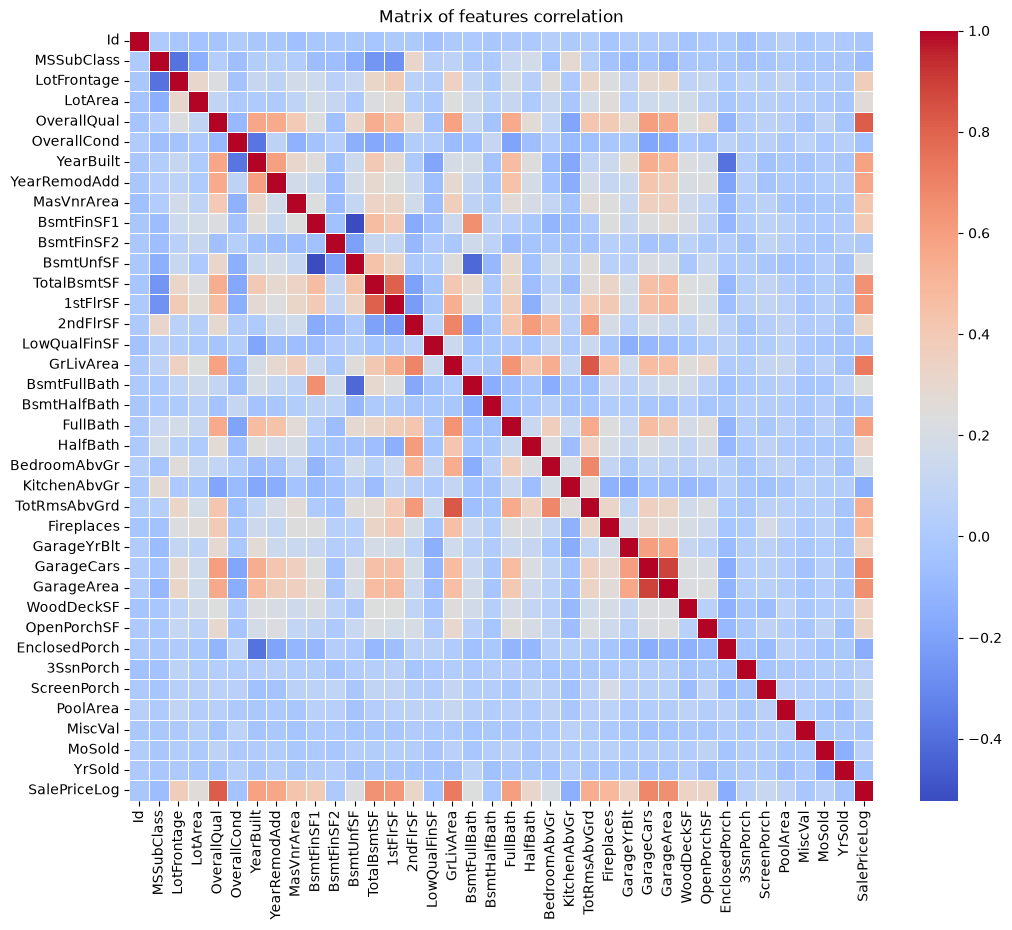

In [14]:
numeric_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation = train[numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matrix of features correlation")
plt.show()

Сильная / заметная / умеренная корреляция согласно heatmap:  
TotalBsmtSF - 1stFlrSF  
GarageCars - GarageArea  
GarageYrBlt - YearBuilt

Отрицательная корреляция:  
BsmtUnfSF - BsmtFinSF1

## Feature engineering

In [16]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

print(train[['TotalSF', 'SalePriceLog']].corr())

               TotalSF  SalePriceLog
TotalSF       1.000000      0.825326
SalePriceLog  0.825326      1.000000


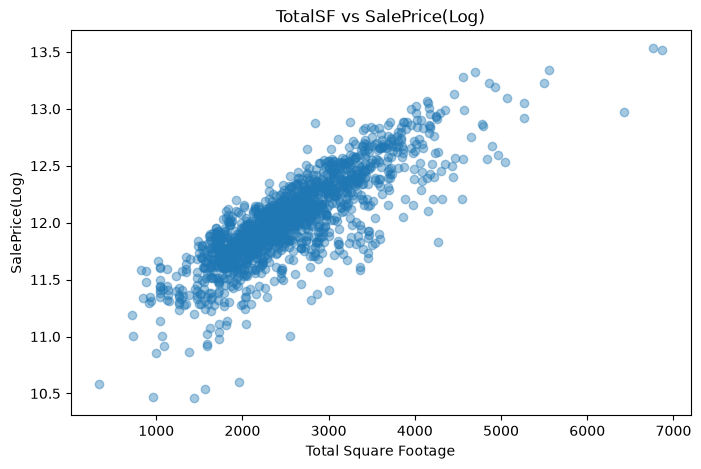

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(train['TotalSF'], train['SalePriceLog'], alpha=0.4)
plt.title('TotalSF vs SalePrice(Log)')
plt.xlabel('Total Square Footage')
plt.ylabel('SalePrice(Log)')
plt.show()

In [19]:
train['TotalBath'] = (train['FullBath'] + train['HalfBath'] * 0.5 + train['BsmtFullBath'] + train['BsmtHalfBath'] * 0.5)
test['TotalBath'] = (test['FullBath'] + test['HalfBath'] * 0.5 + test['BsmtFullBath'] + test['BsmtHalfBath'] * 0.5)

HalfBath (туалет без душа/ванны) считается за 0.5 от полноценного санузла

In [20]:
print(train[['TotalBath', 'SalePriceLog']].corr())

              TotalBath  SalePriceLog
TotalBath      1.000000      0.676678
SalePriceLog   0.676678      1.000000


Корреляция между количеством ванных комнат и ценой

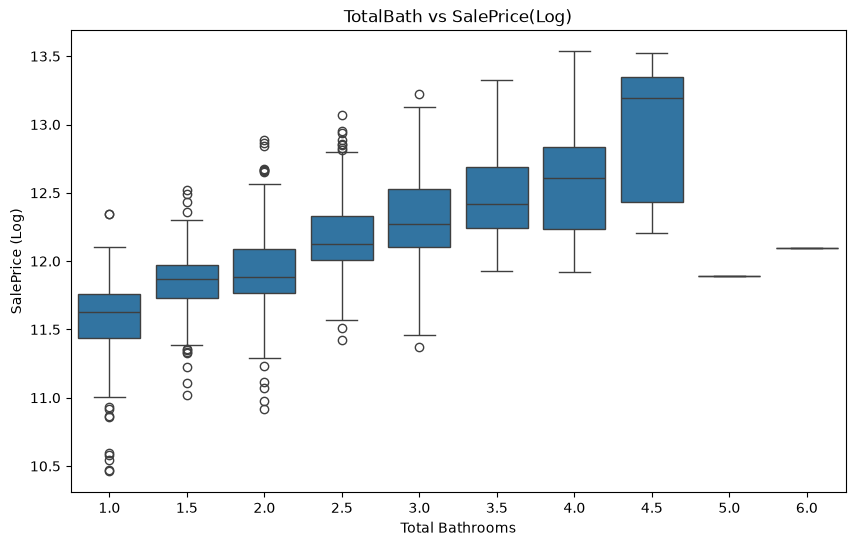

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=train['TotalBath'], y=train['SalePriceLog'])
plt.title('TotalBath vs SalePrice(Log)')
plt.xlabel('Total Bathrooms')
plt.ylabel('SalePrice (Log)')
plt.show()

In [22]:
print(train['TotalBath'].value_counts().sort_index())

TotalBath
1.0    228
1.5    129
2.0    456
2.5    295
3.0    186
3.5    144
4.0     13
4.5      5
5.0      1
6.0      1
Name: count, dtype: int64


Применим биннинг

In [23]:
def bin_total_bath(x):
    if x <= 1.5:
        return 0 # Few
    elif x <= 2.5:
        return 1 # Standard
    elif x<= 3.5:
        return 2 # Many
    else:
        return 3 # Lux (4+)

train['TotalBathBin'] = train['TotalBath'].apply(bin_total_bath)
test['TotalBathBin'] = test['TotalBath'].apply(bin_total_bath)

print(train['TotalBathBin'].value_counts().sort_index())
print(train.groupby('TotalBathBin')['SalePriceLog'].median())

TotalBathBin
0    357
1    751
2    330
3     20
Name: count, dtype: int64
TotalBathBin
0    11.699413
1    12.013101
2    12.344655
3    12.520047
Name: SalePriceLog, dtype: float64


Создадим фичи которая позволит модели лучше интерпретировать фичи связанные с годами построки, продажи,  
заведомо убедясь в отсутствии отрицательных значений новых фичей

In [24]:
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

train['YearsSinceRemod'] = train['YrSold'] - train['YearRemodAdd']
test['YearsSinceRemod'] = test['YrSold'] - test['YearRemodAdd']

In [25]:
print('Min House Age:', train['HouseAge'].min())
print('Min YearsSinceRemod:', train['YearsSinceRemod'].min())

Min House Age: 0
Min YearsSinceRemod: 0


Теперь можем взглянуть на корреляцию

In [26]:
print(train[['HouseAge', 'YearsSinceRemod', 'SalePriceLog']].corr())

                 HouseAge  YearsSinceRemod  SalePriceLog
HouseAge         1.000000         0.593432     -0.587767
YearsSinceRemod  0.593432         1.000000     -0.568529
SalePriceLog    -0.587767        -0.568529      1.000000


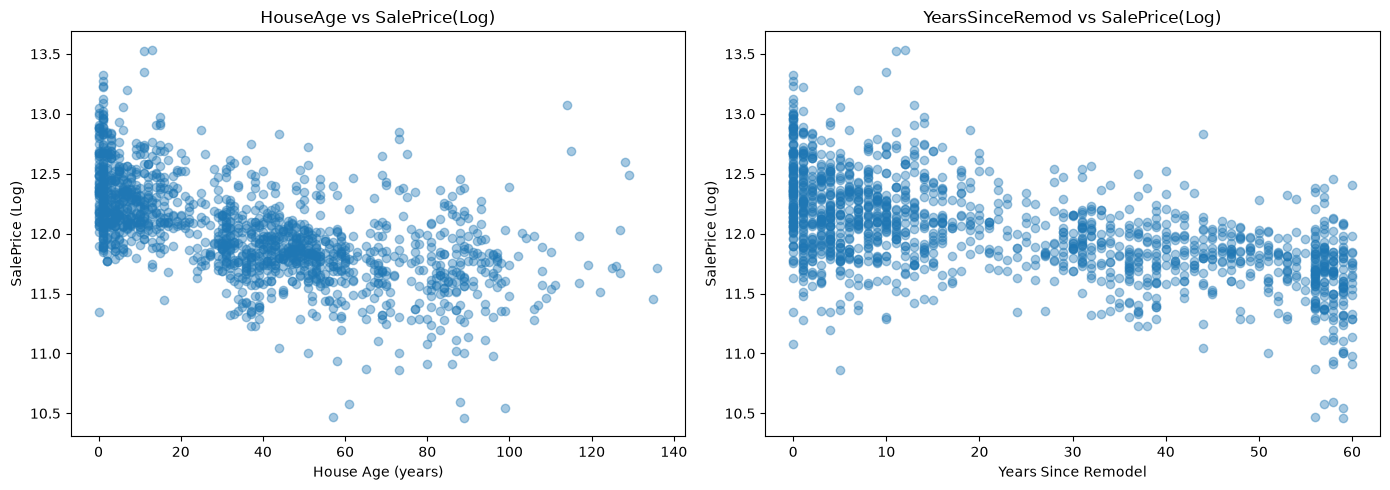

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train['HouseAge'], train['SalePriceLog'], alpha=0.4)
axes[0].set_title('HouseAge vs SalePrice(Log)')
axes[0].set_xlabel('House Age (years)')
axes[0].set_ylabel('SalePrice (Log)')

axes[1].scatter(train['YearsSinceRemod'], train['SalePriceLog'], alpha=0.4)
axes[1].set_title('YearsSinceRemod vs SalePrice(Log)')
axes[1].set_xlabel('Years Since Remodel')
axes[1].set_ylabel('SalePrice (Log)')

plt.tight_layout()
plt.show()

Реализация бинарных флагов наличия.  
Также проверим корреляцию этих, предположительно,  
несбалансированных бинарных фичей относительно цены,  
заодно просмотрев количество каждой.

In [28]:
train['HasPool'] = (train['PoolArea'] > 0).astype(int)
test['HasPool'] = (test['PoolArea'] > 0).astype(int)

train['HasGarage'] = (train['GarageArea'] > 0).astype(int)
test['HasGarage'] = (test['GarageArea'] > 0).astype(int)

train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)
test['HasFireplace'] = (test['Fireplaces'] > 0).astype(int)

train['HasBasement'] = (train['TotalBsmtSF'] > 0).astype(int)
test['HasBasement'] = (test['TotalBsmtSF'] > 0).astype(int)

for col in ['HasPool', 'HasGarage', 'HasFireplace', 'HasBasement']:
    print(f'\n{col}:')
    print(train.groupby(col)['SalePriceLog'].agg(['median', 'count']))


HasPool:
            median  count
HasPool                  
0        12.000898   1452
1        12.398283      6

HasGarage:
              median  count
HasGarage                  
0          11.512935     81
1          12.028745   1377

HasFireplace:
                 median  count
HasFireplace                  
0             11.813037    690
1             12.160034    768

HasBasement:
                median  count
HasBasement                  
0            11.530775     37
1            12.013707   1421
